In [ ]:
from pathlib import Path
import json

DATA_NAME = "SLEEP"
DATA_DIR = Path(DATA_NAME)

DATA_INFO_PATH = DATA_DIR / "dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [ ]:
import h5py
import numpy as np

INDEX_PATH_TRAIN = DATA_DIR / "train.h5"
INDEX_PATH_VAL = DATA_DIR / "val.h5"
INDEX_PATH_TEST = DATA_DIR / "test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [3]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [4]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        num_classes,
        time_points=200,
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [5]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [6]:
from RNN_Exercise import ExerciseEEGLSTM

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


加载数据...
降采样后数据形状: torch.Size([3921, 6, 1500])
类别权重: tensor([0.9852, 1.0028, 0.9803, 0.9803, 1.0555])
模型参数量: 11,136

开始训练改进版EEGNet...
训练集大小: 3921, 验证集大小: 1941
BATCH_SIZE: 32, EPOCHS: 150

动态计算特征维度: 3008
Epoch [001/150] | LR: 5.00e-04 | Train Loss: 1.6232 | Train Acc: 0.1943 | Val Loss: 1.6137 | Val Acc: 0.1891
Epoch [002/150] | LR: 5.00e-04 | Train Loss: 1.6091 | Train Acc: 0.2122 | Val Loss: 1.6093 | Val Acc: 0.2210
Epoch [003/150] | LR: 5.00e-04 | Train Loss: 1.5989 | Train Acc: 0.2331 | Val Loss: 1.5980 | Val Acc: 0.2442
Epoch [004/150] | LR: 4.99e-04 | Train Loss: 1.5865 | Train Acc: 0.2433 | Val Loss: 1.5921 | Val Acc: 0.2499
Epoch [005/150] | LR: 4.99e-04 | Train Loss: 1.5862 | Train Acc: 0.2428 | Val Loss: 1.5867 | Val Acc: 0.2674
Epoch [006/150] | LR: 4.98e-04 | Train Loss: 1.5777 | Train Acc: 0.2507 | Val Loss: 1.5805 | Val Acc: 0.2535
Epoch [007/150] | LR: 4.97e-04 | Train Loss: 1.5763 | Train Acc: 0.2499 | Val Loss: 1.5847 | Val Acc: 0.2720
Epoch [008/150] | LR: 4.96e-04 | Tr

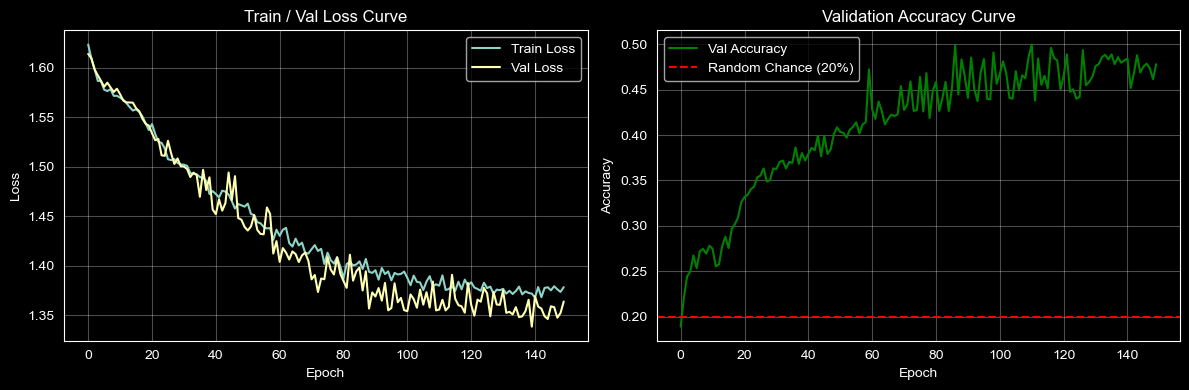

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x12000 and 3008x128)

In [7]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, Dataset
from TEST_DATASET import TrainDataset, TestDataset
from sklearn.utils.class_weight import compute_class_weight


CHANNELS = 6
original_patch_size = 6000
CLASSES = 5
BATCH_SIZE = 32
EPOCHS = 150
LR = 5e-4
PRINT_EPOCH_FREQ = 1

# -------------------------
# 降采样函数
# -------------------------
def downsample(data, target_len=1500):
    """将时间维度降采样到target_len"""
    original_len = data.shape[-1]
    step = original_len // target_len
    return data[:, :, ::step]

# -------------------------
# 数据加载（带降采样）
# -------------------------
print("加载数据...")
train_ds_raw = TrainDataset(INDEX_PATH_TRAIN)
val_ds_raw = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

# 应用降采样
target_len = 1500  # 7.5秒 @200Hz
train_ds_raw.x = downsample(train_ds_raw.x, target_len)
val_ds_raw.x = downsample(val_ds_raw.x, target_len)
patch_size = target_len

print(f"降采样后数据形状: {train_ds_raw.x.shape}")

# -------------------------
# 计算类别权重（处理类别不平衡）
# -------------------------
y_train = train_ds_raw.y.numpy()
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(f"类别权重: {class_weights}")

# -------------------------
# 创建DataLoader
# -------------------------
train_loader = DataLoader(train_ds_raw, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds_raw, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

# -------------------------
# 改进的EEGNetClassifier（修正版）
# -------------------------
class ImprovedEEGNetClassifier(nn.Module):
    """改进版EEGNet，更适合长时间序列"""
    def __init__(self, chans, time_point, num_classes, f1=16, d=2, dp=0.3):
        super().__init__()
        f2 = f1 * d

        # Block 1: 时间卷积
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(f1),
            nn.Conv2d(f1, f1, (1, 32), padding=(0, 16), bias=False),
            nn.BatchNorm2d(f1),
            nn.ELU(),
        )

        # Block 2: 深度可分离空间卷积
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, 4), stride=4),
            nn.Dropout(dp)
        )

        # Block 3: 可分离卷积
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0, 8)),
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, 4), stride=4),
            nn.Dropout(dp)
        )

        # 使用一个辅助前向来计算特征维度
        self.embed_dim = None
        self.num_classes = num_classes
        self.f2 = f2

        # 分类头（将在第一次前向时动态创建）
        self.classifier = None

    def forward(self, x):
        # x: (B, C, T)
        if len(x.shape) == 3:
            x = x.unsqueeze(1)  # (B, 1, C, T)

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.flatten(start_dim=1)

        # 动态创建分类头
        if self.classifier is None:
            self.embed_dim = x.shape[1]
            self.classifier = nn.Sequential(
                nn.Linear(self.embed_dim, 128),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(128, self.num_classes)
            ).to(x.device)
            print(f"动态计算特征维度: {self.embed_dim}")

        return self.classifier(x)

# -------------------------
# 创建模型
# -------------------------
model = ImprovedEEGNetClassifier(
    chans=CHANNELS,
    time_point=patch_size,
    num_classes=CLASSES,
    f1=16,
    d=2,
    dp=0.3
)

print(f"模型参数量: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# 余弦退火学习率调度器
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# -------------------------
# 记录曲线
# -------------------------
train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0.0

# -------------------------
# 训练循环
# -------------------------
print("\n开始训练改进版EEGNet...")
print(f"训练集大小: {len(train_ds_raw)}, 验证集大小: {len(val_ds_raw)}")
print(f"BATCH_SIZE: {BATCH_SIZE}, EPOCHS: {EPOCHS}\n")

for epoch in range(EPOCHS):
    # ===== Train =====
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_num = 0

    for data, label in train_loader:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()

        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        batch_size = label.size(0)
        train_loss_sum += loss.item() * batch_size
        train_num += batch_size

        pred = torch.argmax(output, dim=1)
        train_correct += (pred == label).sum().item()

    epoch_train_loss = train_loss_sum / train_num
    epoch_train_acc = train_correct / train_num
    train_losses.append(epoch_train_loss)

    # ===== Val =====
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_num = 0

    with torch.no_grad():
        for val_data, val_label in val_loader:
            val_output = model(val_data)
            val_loss = criterion(val_output, val_label)

            batch_size = val_label.size(0)
            val_loss_sum += val_loss.item() * batch_size
            val_num += batch_size

            val_pred = torch.argmax(val_output, dim=1)
            val_correct += (val_pred == val_label).sum().item()

    epoch_val_loss = val_loss_sum / val_num
    epoch_val_acc = val_correct / val_num

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    # 更新学习率
    scheduler.step()

    # 保存最佳模型
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), f'{DATA_NAME}/best_model.pth')

    # 输出结果
    if (epoch + 1) % PRINT_EPOCH_FREQ == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
            f"LR: {current_lr:.2e} | "
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

# -------------------------
# 输出最终结果
# -------------------------
print("\n" + "-" * 60)
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"Final Val Accuracy: {val_accuracies[-1]:.4f}")

# 加载最佳模型进行测试
if best_val_acc > 0:
    model.load_state_dict(torch.load(f'{DATA_NAME}/best_model.pth'))

# -------------------------
# 画图
# -------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, label="Train Loss")
ax1.plot(val_losses, label="Val Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Train / Val Loss Curve")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(val_accuracies, label="Val Accuracy", color='green')
ax2.axhline(y=0.2, color='red', linestyle='--', label='Random Chance (20%)')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy Curve")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------
# test 推理示例
# -------------------------
test_data = next(iter(test_loader))
print("-" * 60)
print("Test input shape:", test_data.shape)

## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [ ]:
# -------------------------
# 保存 test 预测标签（每行一个数字）
# -------------------------
model.eval()
output_path = f'{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")